In [ ]:
# Assessing a Single Classification Algorithm ##
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
import numpy as np

# Load the dataset
data = load_iris()
X, y = data.data, data.target

# Define the model (Support Vector Classifier in this case)
model = SVC()

# Set the number of folds (K = 5)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform K-fold cross-validation and get the performance metrics
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# Perform cross-validation
results = cross_validate(model, X, y, cv=kfold, scoring=scoring)

# Print results for each metric
print("Accuracy: ", np.mean(results['test_accuracy']))
print("Precision: ", np.mean(results['test_precision_macro']))
print("Recall: ", np.mean(results['test_recall_macro']))
print("F1 Score: ", np.mean(results['test_f1_macro']))


In [2]:
#Comparing two Models
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Load the dataset
data = load_iris()
  #read_csv("")
X, y = data.data, data.target

# Define the two models
model_1 = SVC()  # Support Vector Classifier
model_2 = RandomForestClassifier()  # Random Forest Classifier

# Set the number of folds (K = 5)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Define performance metrics to calculate
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# Perform K-fold cross-validation for both models
results_model_1 = cross_validate(model_1, X, y, cv=kfold, scoring=scoring)
results_model_2 = cross_validate(model_2, X, y, cv=kfold, scoring=scoring)

# Function to print results
def print_results(results, model_name):
    print(f"\nPerformance of {model_name}:")
    print(f"Accuracy: {np.mean(results['test_accuracy']):.4f} (±{np.std(results['test_accuracy']):.4f})")
    print(f"Precision: {np.mean(results['test_precision_macro']):.4f} (±{np.std(results['test_precision_macro']):.4f})")
    print(f"Recall: {np.mean(results['test_recall_macro']):.4f} (±{np.std(results['test_recall_macro']):.4f})")
    print(f"F1 Score: {np.mean(results['test_f1_macro']):.4f} (±{np.std(results['test_f1_macro']):.4f})")

# Print results for both models
print_results(results_model_1, "Support Vector Classifier")
print_results(results_model_2, "Random Forest Classifier")

# Optional: Compare models based on mean F1 Score
f1_diff = np.mean(results_model_2['test_f1_macro']) - np.mean(results_model_1['test_f1_macro'])
print(f"\nDifference in F1-Score (Random Forest - SVC): {f1_diff:.4f}")



Performance of Support Vector Classifier:
Accuracy: 0.9667 (±0.0298)
Precision: 0.9672 (±0.0309)
Recall: 0.9672 (±0.0309)
F1 Score: 0.9670 (±0.0308)

Performance of Random Forest Classifier:
Accuracy: 0.9600 (±0.0249)
Precision: 0.9628 (±0.0243)
Recall: 0.9594 (±0.0243)
F1 Score: 0.9589 (±0.0258)

Difference in F1-Score (Random Forest - SVC): -0.0081


In [ ]:
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score,mean_squared_error
import numpy as np

# Load a binary classification dataset (Breast Cancer dataset)
data = load_breast_cancer()
X, y = data.data, data.target

# Define the linear regression model (for classification purposes)
model = LinearRegression()

# Set the number of folds (K = 5)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and get predicted values
y_pred = cross_val_predict(model, X, y, cv=kfold)

# Convert regression predictions to binary classification (threshold = 0.5)
y_pred_class = np.where(y_pred >= 0.5, 1, 0)

# Calculate classification performance metrics
accuracy = accuracy_score(y, y_pred_class)
precision = precision_score(y, y_pred_class)
recall = recall_score(y, y_pred_class)
f1 = f1_score(y, y_pred_class)
conf_matrix = confusion_matrix(y, y_pred_class)
mse = mean_squared_error(y, y_pred_class)

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print(f"\nMSE score :{mse:.4f}")

In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# Example dataset (replace with your dataset)
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X, y = data.data, data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train the Logistic Regression model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability estimates

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print performance metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)


In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Load the dataset (assuming CSV format)
# Example: 'telecom_customer_churn.csv'
data = pd.read_csv('churn_data.csv')

# View the first few rows of the data
print(data.head())

# Data preprocessing
# Assuming 'Churn' is the target column (1 if customer churned, 0 otherwise)

# Handle missing values (if any)
data.fillna(method='ffill', inplace=True)

# Convert categorical features to numerical (dummy variables or one-hot encoding)
data = pd.get_dummies(data, drop_first=True)
print(data.columns)
# Separate features and target variable
X = data.drop(columns='Churn_Yes')  # Features
y = data['Churn_Yes']               # Target variable (1 = churned, 0 = not churned)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Feature scaling (optional but recommended for Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for ROC-AUC

# Evaluate the model using performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print performance metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Print confusion matrix
print("\nConfusion Matrix:")
print(conf_matrix)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Calculate false positive rate and true positive rate for ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris

# Load a multi-class dataset (Iris dataset)
data = load_iris()
X, y = data.data, data.target  # 3 classes

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Logistic Regression model with OvR (default behavior for multi-class classification)
model = LogisticRegression(multi_class='ovr', max_iter=1000)  # One-vs-Rest (default)
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print results
print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)


In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris

# Load the multi-class dataset (Iris dataset)
data = load_iris()
X, y = data.data, data.target  # 3 classes

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Logistic Regression model with multinomial logistic regression (Softmax)
model = LogisticRegression(multi_class='multinomial', max_iter=1000)  # Softmax Regression
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print results
print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)


Mean Squared Error: 24.29
R² Score: 0.67


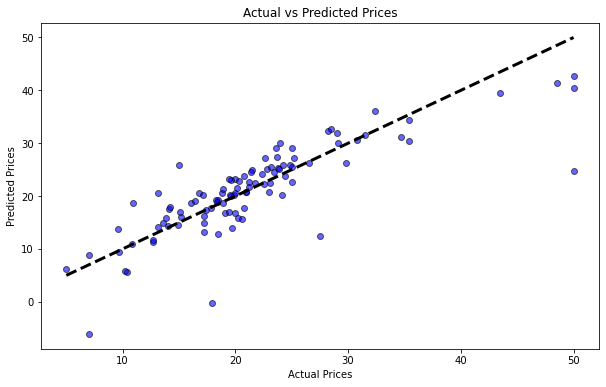

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_boston

# Load the Boston housing dataset
data = load_boston()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['PRICE'] = data.target

# Split the data into features and target
X = df.drop('PRICE', axis=1)
y = df['PRICE']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

# Plot actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()
